In [34]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [35]:
random_state = 42

In [36]:
user_profile_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv"
user_profile_df = pd.read_csv(user_profile_url)
user_profile_df.head()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0
3,7,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0


In [37]:
user_profile_df.shape

(33901, 15)

In [38]:
user_profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000
mean,1.064064e+06,5.518569,3.493791,2.307100,3.624701,0.998938,3.048022,0.001770,5.087343,4.750450,0.462995,1.017433,2.269461,0.315802,0.986844
std,4.972578e+05,7.611941,4.227254,3.841858,4.760135,2.351764,4.624004,0.072846,5.230697,7.216228,1.055186,2.342532,4.310752,1.363462,1.950585
min,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.813480e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.043907e+06,3.000000,3.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.451159e+06,9.000000,6.000000,3.000000,6.000000,0.000000,3.000000,0.000000,9.000000,6.000000,0.000000,0.000000,3.000000,0.000000,2.000000
max,2.103039e+06,63.000000,18.000000,38.000000,48.000000,15.000000,39.000000,3.000000,32.000000,54.000000,6.000000,18.000000,54.000000,15.000000,12.000000


In [39]:
feature_names = user_profile_df.columns[1:].tolist()
feature_names

['Database',
 'Python',
 'CloudComputing',
 'DataAnalysis',
 'Containers',
 'MachineLearning',
 'ComputerVision',
 'DataScience',
 'BigData',
 'Chatbot',
 'R',
 'BackendDev',
 'FrontendDev',
 'Blockchain']

In [40]:
user_profile_df_scaled = user_profile_df.copy()
scaler = StandardScaler()
user_profile_df_scaled[feature_names] = scaler.fit_transform(user_profile_df[feature_names])
user_profile_df_scaled.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04
mean,1.064064e+06,-2.682796e-17,-5.365592e-17,-1.341398e-17,-7.545364e-17,1.341398e-17,3.353495e-17,-7.545364e-18,-2.012097e-17,6.706990e-17,-6.036291e-17,5.700942e-17,2.012097e-17,2.012097e-17,-6.706990e-17
std,4.972578e+05,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,2.000000e+00,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
25%,6.813480e+05,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
50%,1.043907e+06,-3.308757e-01,-1.168130e-01,-6.005256e-01,-1.312380e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-3.990622e-01,-3.811535e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
75%,1.451159e+06,4.573712e-01,5.928781e-01,1.803581e-01,4.990056e-01,-4.247674e-01,-1.038556e-02,-2.429612e-02,7.480294e-01,1.731609e-01,-4.387873e-01,-4.343370e-01,1.694715e-01,-2.316212e-01,5.194189e-01
max,2.103039e+06,7.551593e+00,3.431642e+00,9.290667e+00,9.322416e+00,5.953517e+00,7.775190e+00,4.115884e+01,5.145214e+00,6.824934e+00,5.247500e+00,7.249771e+00,1.200053e+01,1.076995e+01,5.646161e+00


In [41]:
features = user_profile_df_scaled.iloc[:, user_profile_df_scaled.columns != 'user']
features

,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,6.106474,2.485388,0.961242,8.272010,0.850889,6.477594,-0.024296,4.571668,5.023412,1.456642,7.249771,7.360899,6.369323,2.570116
1,4.529980,-0.353377,0.440653,5.120792,-0.424767,2.368540,-0.024296,2.851031,2.667576,-0.438787,2.127032,0.865416,-0.231621,0.519419
2,2.427988,1.066006,4.084776,4.280467,-0.424767,5.828796,-0.024296,3.233395,1.281790,1.456642,5.542191,5.505047,2.702132,2.570116
3,-0.462250,-0.826504,-0.600526,-0.341319,-0.424767,-0.659184,-0.024296,-0.972608,-0.381153,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
4,0.063248,-0.826504,-0.600526,0.078843,-0.424767,-0.659184,-0.024296,-0.972608,0.173161,-0.438787,0.419453,-0.526473,-0.231621,-0.505930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33896,-0.330876,-0.116813,0.180358,0.499006,-0.424767,-0.659184,-0.024296,0.174484,-0.658311,-0.438787,2.127032,0.865416,-0.231621,1.032093
33897,-0.724999,-0.826504,-0.079936,-0.761482,-0.424767,-0.659184,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930
33898,-0.330876,0.592878,0.961242,-0.761482,-0.424767,2.368540,-0.024296,0.748029,-0.658311,-0.438787,0.846348,-0.526473,-0.231621,-0.505930
33899,-0.724999,-0.826504,-0.600526,-0.761482,-0.424767,-0.226652,-0.024296,-0.972608,-0.658311,-0.438787,-0.434337,-0.526473,-0.231621,-0.505930


In [42]:
user_ids = user_profile_df_scaled.iloc[:, user_profile_df_scaled.columns == 'user']
user_ids

,user
0,2
1,4
2,5
3,7
4,8
...,...
33896,2102054
33897,2102356
33898,2102680
33899,2102983


In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(features)

In [45]:
print(features.shape)
print(X_pca.shape)

(33901, 14)
(33901, 10)


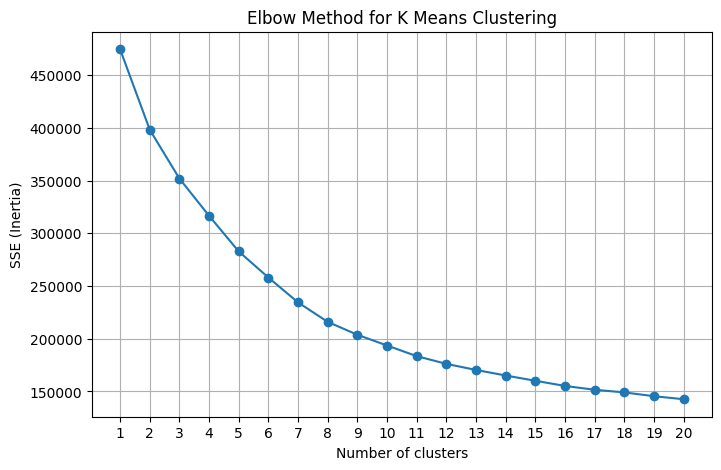

In [46]:
n_clusters = range(1, 21)
sse = []

for k in n_clusters:
    model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    model.fit(features)
    sse.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(n_clusters), sse, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for K Means Clustering")
plt.xticks(list(n_clusters))
plt.grid(True)
plt.show()

In [47]:
model = KMeans(n_clusters=9, random_state=random_state, n_init=10)
model.fit(features)
labels = model.labels_

In [48]:
def combine_cluster_labels(user_ids, labels):
    user_df = pd.DataFrame({'user': user_ids})
    labels_df = pd.DataFrame({'cluster': labels})
    cluster_df = pd.concat([user_df.reset_index(drop=True), labels_df.reset_index(drop=True)], axis=1)
    return cluster_df

In [49]:
cluster_df = combine_cluster_labels(user_ids['user'].values, labels)
cluster_df.head()

,user,cluster
0,2,3
1,4,3
2,5,3
3,7,2
4,8,2


In [50]:
cluster_profile = user_profile_df.merge(cluster_df, on='user', how="inner", validate="many_to_many")
cluster_profile.head()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,cluster
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0,3
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0,3
2,5,24.0,8.0,18.0,24.0,0.0,30.0,0.0,22.0,14.0,2.0,14.0,26.0,4.0,6.0,3
3,7,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,2
4,8,6.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0,2


In [56]:
import numpy as np

def average_new_recommendations(data_with_cluster, course_columns, top_n=10):
    counts = []

    for _, row in data_with_cluster.iterrows():
        user = row['user']
        cluster = row['cluster']
        cluster_users = data_with_cluster[data_with_cluster['cluster'] == cluster]
        cluster_users = cluster_users[cluster_users['user'] != user]
        cluster_mean = (cluster_users[course_columns] > 0).mean()
        user_seen = row[course_columns] > 0
        unseen_scores = cluster_mean[~user_seen]
        recommended = unseen_scores.sort_values(ascending=False).index[:top_n]
        counts.append(len(recommended))

    return np.mean(counts)

In [57]:
avg_new = average_new_recommendations(cluster_profile, features.columns, top_n=5)
print(avg_new)

4.891065160319755


In [62]:
from collections import Counter

def most_frequent_recommendations(data_with_cluster, course_columns, top_n=10):
    all_recommendations = []

    for _, row in data_with_cluster.iterrows():
        user = row['user']
        cluster = row['cluster']

        cluster_users = data_with_cluster[data_with_cluster['cluster'] == cluster]
        cluster_users = cluster_users[cluster_users['user'] != user]

        if cluster_users.empty:
            continue

        cluster_mean = (cluster_users[course_columns] > 0).mean()
        user_seen = row[course_columns] > 0

        unseen_scores = cluster_mean[~user_seen]
        recommended = unseen_scores.sort_values(ascending=False).index[:top_n]

        all_recommendations.extend(recommended)

    course_counts = Counter(all_recommendations)
    df = pd.DataFrame(course_counts.items(), columns=['course', 'count'])
    return df.sort_values(by='count', ascending=False).head(10).reset_index(drop=True)

In [63]:
top_courses = most_frequent_recommendations(cluster_profile, features.columns, top_n=5)
top_courses

,course,count
0,Blockchain,20744
1,CloudComputing,18649
2,MachineLearning,16820
3,BigData,16602
4,Database,14318
5,BackendDev,11753
6,R,11632
7,DataScience,10252
8,Containers,9356
9,DataAnalysis,8872
